In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [11]:
df = pd.read_csv("../data/raw/fedfunds.csv")

df["DATE"] = pd.to_datetime(df["DATE"])

df.set_index("DATE", inplace=True)

KeyError: 'DATE'

In [12]:
print(df.columns)

Index(['observation_date', 'FEDFUNDS'], dtype='str')


In [13]:
df = pd.read_csv('../data/raw/fedfunds.csv')

print(df.columns)

Index(['observation_date', 'FEDFUNDS'], dtype='str')


In [14]:
df["Date"] = pd.to_datetime(df["Date"])

df.set_index("Date", inplace=True)

KeyError: 'Date'

In [15]:
df = pd.read_csv('../data/raw/fedfunds.csv')

print(df.columns.tolist())

['observation_date', 'FEDFUNDS']


In [16]:
df.head()

,observation_date,FEDFUNDS
0,1954-07-01,0.80
1,1954-08-01,1.22
2,1954-09-01,1.07
3,1954-10-01,0.85
4,1954-11-01,0.83


In [17]:
df["observation_date"] = pd.to_datetime(df["observation_date"])

df.set_index("observation_date", inplace=True)

In [18]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 863 entries, 1954-07-01 to 2026-05-01
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   FEDFUNDS  863 non-null    float64
dtypes: float64(1)
memory usage: 13.5 KB


In [19]:
df.head()

,FEDFUNDS
observation_date,
1954-07-01,0.80
1954-08-01,1.22
1954-09-01,1.07
1954-10-01,0.85
1954-11-01,0.83


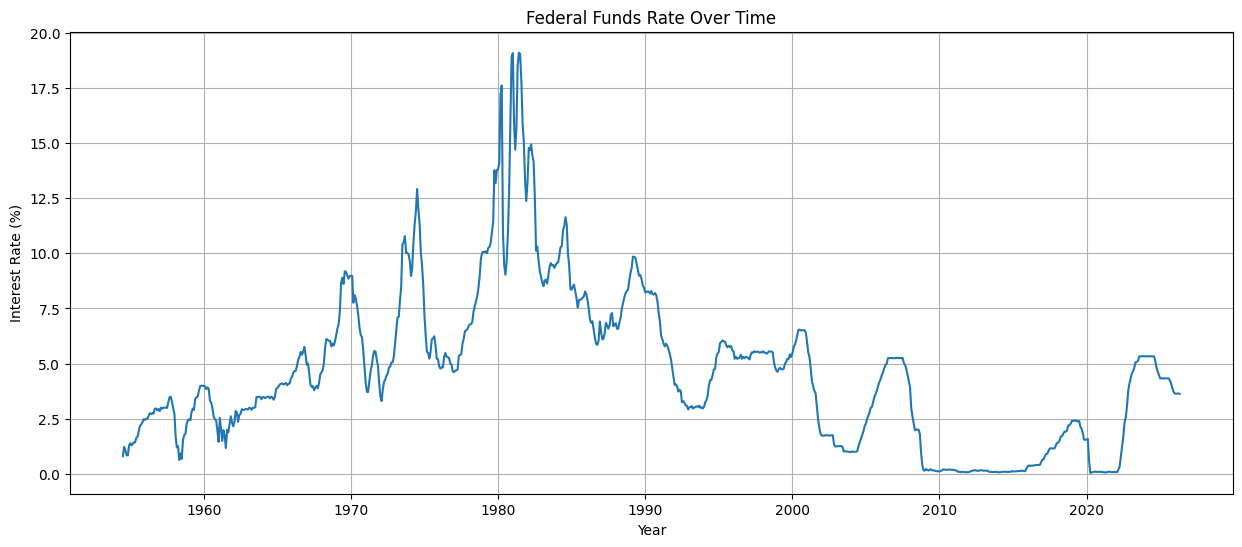

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

plt.plot(df.index, df["FEDFUNDS"])

plt.title("Federal Funds Rate Over Time")

plt.xlabel("Year")

plt.ylabel("Interest Rate (%)")

plt.grid(True)

plt.show()

In [21]:
df["FEDFUNDS"].max()

np.float64(19.1)

In [22]:
df["FEDFUNDS"].idxmax()

Timestamp('1981-06-01 00:00:00')

In [23]:
df["FEDFUNDS"].min()

np.float64(0.05)

In [24]:
df["FEDFUNDS"].idxmin()

Timestamp('2020-04-01 00:00:00')

In [25]:
df["Rolling_12M"] = df["FEDFUNDS"].rolling(window=12).mean()

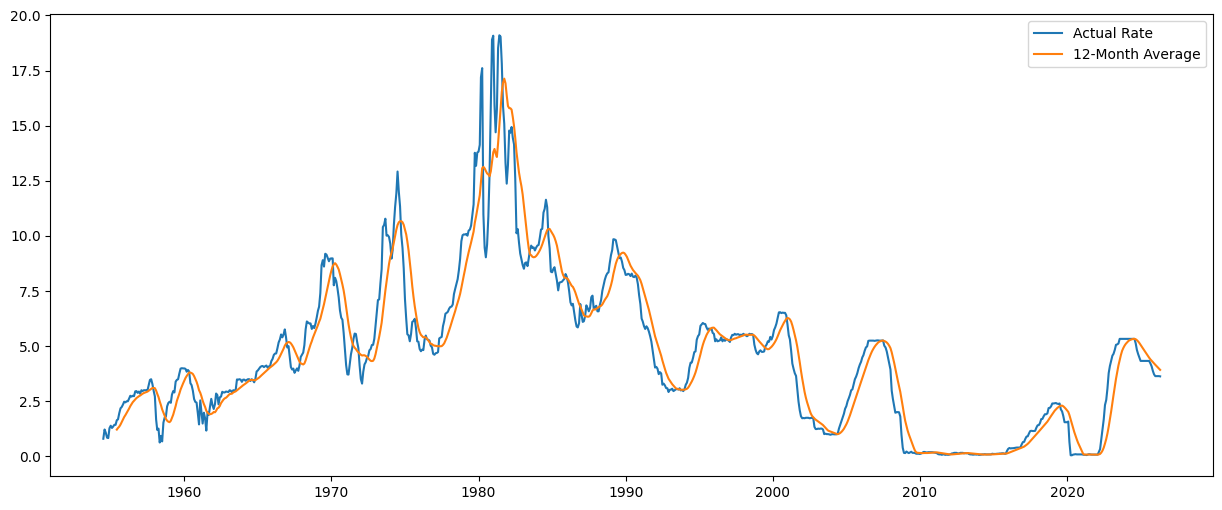

In [26]:
plt.figure(figsize=(15,6))

plt.plot(df.index, df["FEDFUNDS"], label="Actual Rate")

plt.plot(df.index, df["Rolling_12M"], label="12-Month Average")

plt.legend()

plt.show()

In [27]:
df["Monthly_Change"] = df["FEDFUNDS"].diff()

In [28]:
df.head()

,FEDFUNDS,Rolling_12M,Monthly_Change
observation_date,,,
1954-07-01,0.80,NaN,NaN
1954-08-01,1.22,NaN,0.42
1954-09-01,1.07,NaN,-0.15
1954-10-01,0.85,NaN,-0.22
1954-11-01,0.83,NaN,-0.02


In [29]:
df["Volatility"] = (
    df["Monthly_Change"]
      .rolling(window=12)
      .std()
)

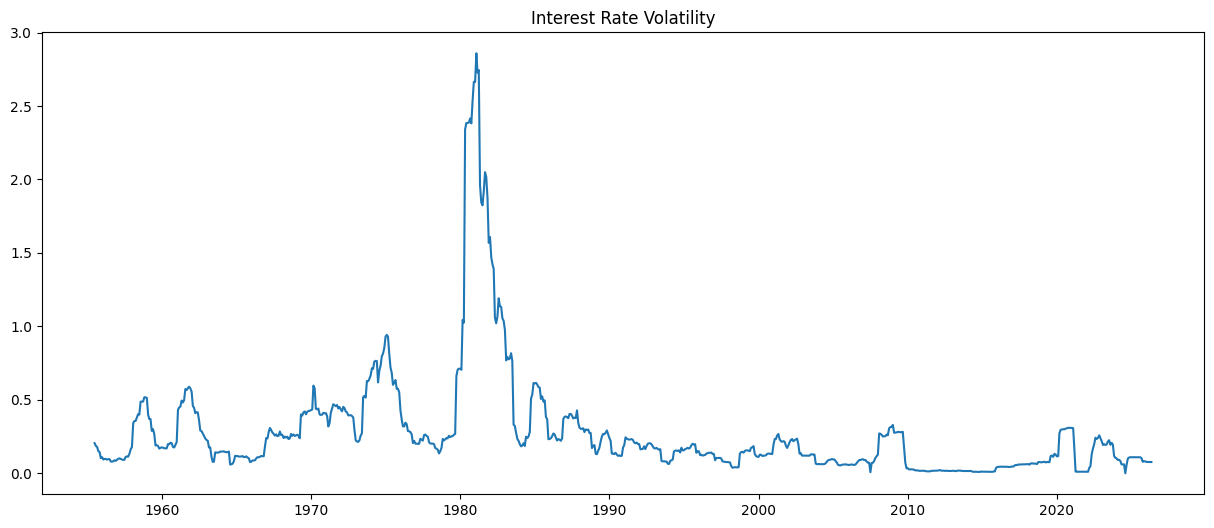

In [30]:
plt.figure(figsize=(15,6))

plt.plot(df.index, df["Volatility"])

plt.title("Interest Rate Volatility")

plt.show()

In [31]:
Q1 = df["FEDFUNDS"].quantile(0.25)

Q3 = df["FEDFUNDS"].quantile(0.75)

IQR = Q3 - Q1

In [32]:
upper = Q3 + 1.5 * IQR

In [33]:
lower = Q1 - 1.5 * IQR

In [34]:
outliers = df[
    (df["FEDFUNDS"] > upper)
    |
    (df["FEDFUNDS"] < lower)
]

outliers.head()

,FEDFUNDS,Rolling_12M,Monthly_Change,Volatility
observation_date,,,,
1974-07-01,12.92,10.492500,0.99,0.618341
1979-10-01,13.77,10.596667,2.34,0.661836
1979-11-01,13.18,10.881667,-0.59,0.705801
1979-12-01,13.78,11.194167,0.60,0.711568
1980-01-01,13.82,11.506667,0.04,0.711568


## EDA Findings

1. Interest rates exhibit long-term cycles.
2. Extremely high rates occurred during inflation-control periods.
3. Near-zero rates occurred during crisis recovery periods.
4. Volatility changes significantly across decades.
5. The dataset contains meaningful extreme observations.
6. Data is suitable for stochastic interest-rate modelling.